# 🛡️ DeepGuard - Image Deepfake Detection Model Training

This notebook trains an image-based deepfake detection model using the **140k Real and Fake Faces** dataset.

## Dataset Info
- **Source:** Kaggle - `xhlulu/140k-real-and-fake-faces`
- **Size:** ~140,000 images (~5GB)
- **Classes:** Real faces vs Fake/Generated faces

## Step 1: Setup & Install Dependencies

In [8]:
!pip install -q kaggle datasets torch torchvision facenet-pytorch pillow tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.6 MB/s eta 0:00:00a 0:00:01


## Step 2: Upload Kaggle API Key

Upload your `kaggle.json` file below. You can get it from: https://www.kaggle.com/settings → API → Create New Token

In [12]:
import os
os.environ['KAGGLE_USERNAME'] = 'prathamcu823'
os.environ['KAGGLE_KEY'] = '576fb3d57e703f4f744ba3985d6e6b44'
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"prathamcu823","key":"576fb3d57e703f4f744ba3985d6e6b44"}')
!chmod 600 /root/.kaggle/kaggle.json
print("✅ Kaggle configured!")

✅ Kaggle configured!


## Step 3: Download the 140k Real and Fake Faces Dataset

In [13]:
import os

# Create dataset directory
DATASET_DIR = "/content/dataset"
os.makedirs(DATASET_DIR, exist_ok=True)

# Download the dataset
print("📥 Downloading 140k Real and Fake Faces dataset...")
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p {DATASET_DIR}

# Unzip the dataset
print("\n📦 Extracting dataset...")
!unzip -q {DATASET_DIR}/140k-real-and-fake-faces.zip -d {DATASET_DIR}

# Remove the zip file to save space
!rm {DATASET_DIR}/140k-real-and-fake-faces.zip

print("\n✅ Dataset downloaded and extracted!")
!ls -la {DATASET_DIR}

📥 Downloading 140k Real and Fake Faces dataset...
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.73G/3.75G [00:42<00:00, 51.7MB/s]
100% 3.75G/3.75G [00:42<00:00, 94.0MB/s]

📦 Extracting dataset...

✅ Dataset downloaded and extracted!
total 21328
drwxr-xr-x 3 root root     4096 Jan  6 16:32 .
drwxr-xr-x 1 root root     4096 Jan  6 16:29 ..
drwxr-xr-x 3 root root     4096 Jan  6 16:30 real_vs_fake
-rw-r--r-- 1 root root  3087819 Feb 10  2020 test.csv
-rw-r--r-- 1 root root 15627819 Feb 10  2020 train.csv
-rw-r--r-- 1 root root  3107819 Feb 10  2020 valid.csv


## Step 4: Explore Dataset Structure

In [14]:
import os
from pathlib import Path

DATASET_DIR = "/content/dataset"

# Explore the dataset structure
print("📁 Dataset Structure:")
for root, dirs, files_list in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for d in dirs[:5]:
            print(f"{subindent}{d}/")
        if len(dirs) > 5:
            print(f"{subindent}... and {len(dirs) - 5} more directories")
        for f in files_list[:3]:
            print(f"{subindent}{f}")
        if len(files_list) > 3:
            print(f"{subindent}... and {len(files_list) - 3} more files")

📁 Dataset Structure:
dataset/
  real_vs_fake/
  test.csv
  train.csv
  valid.csv
  real_vs_fake/
    real-vs-fake/
    real-vs-fake/
      train/
        fake/
        real/
      test/
        fake/
        real/
      valid/
        fake/
        real/


## Step 5: Create PyTorch Dataset & DataLoaders

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from pathlib import Path
from tqdm import tqdm

class DeepfakeDataset(Dataset):
    """Custom Dataset for Real vs Fake face classification"""
    
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = [] 
        self.labels = []
        
        # Dataset structure: real_vs_fake/real-vs-fake/{split}/real or fake
        base_path = self.root_dir / 'real_vs_fake' / 'real-vs-fake' / split
        
        # Load real images (label = 0)
        real_path = base_path / 'real'
        if real_path.exists():
            for img_file in real_path.glob('*.jpg'):
                self.samples.append(str(img_file))
                self.labels.append(0)
            for img_file in real_path.glob('*.png'):
                self.samples.append(str(img_file))
                self.labels.append(0)
        
        # Load fake images (label = 1)
        fake_path = base_path / 'fake'
        if fake_path.exists():
            for img_file in fake_path.glob('*.jpg'):
                self.samples.append(str(img_file))
                self.labels.append(1)
            for img_file in fake_path.glob('*.png'):
                self.samples.append(str(img_file))
                self.labels.append(1)
        
        print(f"Loaded {len(self.samples)} images for {split} split")
        print(f"  - Real: {self.labels.count(0)}, Fake: {self.labels.count(1)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path = self.samples[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
DATASET_DIR = "/content/dataset"

train_dataset = DeepfakeDataset(DATASET_DIR, split='train', transform=train_transform)
val_dataset = DeepfakeDataset(DATASET_DIR, split='valid', transform=val_transform)
test_dataset = DeepfakeDataset(DATASET_DIR, split='test', transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

Loaded 100000 images for train split
  - Real: 50000, Fake: 50000
Loaded 20000 images for valid split
  - Real: 10000, Fake: 10000
Loaded 20000 images for test split
  - Real: 10000, Fake: 10000

✅ DataLoaders created!
   Train batches: 3125
   Val batches: 625
   Test batches: 625


## Step 6: Visualize Sample Images

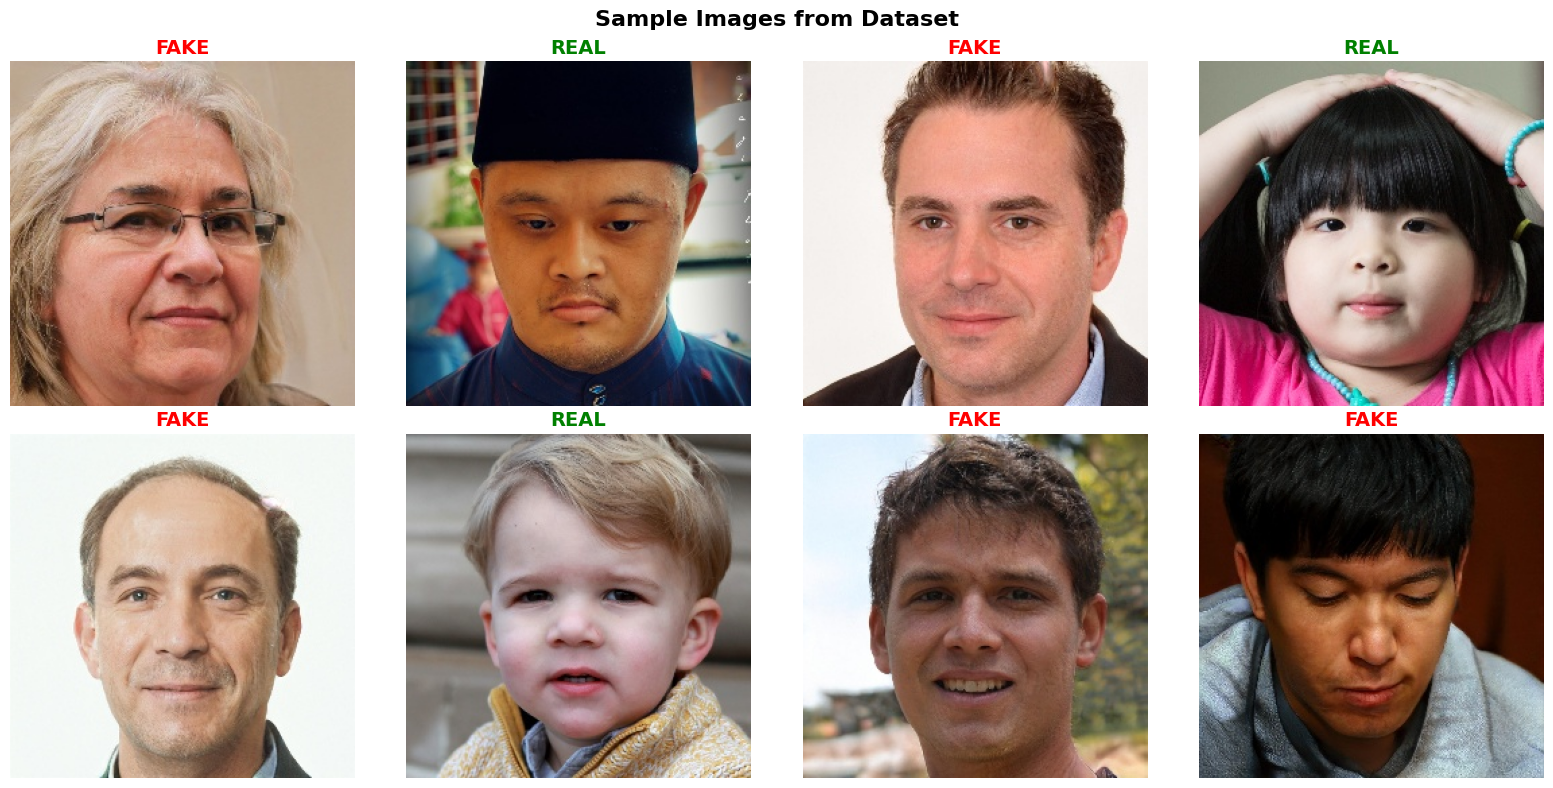

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(dataset, num_samples=8):
    """Display sample images from the dataset"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Get random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for ax, idx in zip(axes, indices):
        # Load original image without transforms
        img_path = dataset.samples[idx]
        label = dataset.labels[idx]
        img = Image.open(img_path).convert('RGB')
        
        ax.imshow(img)
        ax.set_title(f"{'REAL' if label == 0 else 'FAKE'}", 
                     color='green' if label == 0 else 'red',
                     fontsize=14, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show samples
show_samples(train_dataset)

## Step 7: Define the Model (EfficientNet-based)

In [18]:
import torch
import torch.nn as nn
from torchvision import models

class DeepfakeDetector(nn.Module):
    """EfficientNet-based Deepfake Detection Model"""
    
    def __init__(self, num_classes=2, dropout=0.3):
        super(DeepfakeDetector, self).__init__()
        
        # Use EfficientNet-B0 as backbone (good balance of speed and accuracy)
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        # Get the number of features from the classifier
        num_features = self.backbone.classifier[1].in_features
        
        # Replace classifier with custom head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Alternative: ResNet-based model
class DeepfakeDetectorResNet(nn.Module):
    """ResNet-50 based Deepfake Detection Model"""
    
    def __init__(self, num_classes=2, dropout=0.3):
        super(DeepfakeDetectorResNet, self).__init__()
        
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

model = DeepfakeDetector(num_classes=2, dropout=0.3)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model Summary:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

🖥️ Using device: cpu

📊 Model Summary:
   Total parameters: 4,664,446
   Trainable parameters: 4,664,446


## Step 8: Training Setup

In [19]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ============================================
# 🏆 OPTIMAL TRAINING CONFIGURATION
# ============================================

# Hyperparameters
LEARNING_RATE = 3e-4          # Optimal for EfficientNet with AdamW
NUM_EPOCHS = 20               # Good balance of time vs accuracy
PATIENCE = 7                  # Early stopping patience
BATCH_SIZE = 32               # Adjust based on GPU memory (16 if OOM)
WEIGHT_DECAY = 0.01           # L2 regularization

# Loss function with label smoothing (reduces overconfidence)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW optimizer (best for transfer learning)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Cosine Annealing scheduler (better than ReduceLROnPlateau)
scheduler = CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=5,              # Restart every 5 epochs
    T_mult=2,           # Double the restart period each time
    eta_min=1e-6        # Minimum learning rate
)

print("✅ Optimal Training Configuration:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Label Smoothing: 0.1")
print(f"   Optimizer: AdamW")
print(f"   Scheduler: CosineAnnealingWarmRestarts")

✅ Optimal Training Configuration:
   Learning Rate: 0.0003
   Epochs: 20
   Batch Size: 32
   Weight Decay: 0.01
   Label Smoothing: 0.1
   Optimizer: AdamW
   Scheduler: CosineAnnealingWarmRestarts


## Step 9: Training Loop

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Train for one epoch with gradient clipping"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    
    return epoch_loss, epoch_acc, epoch_f1

# ============================================
# 🚀 TRAINING LOOP
# ============================================

print("\n🚀 Starting Training...\n")
print("=" * 70)

best_val_loss = float('inf')
best_val_acc = 0.0
best_val_f1 = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Track history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - start_time
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) | LR: {current_lr:.2e}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    # Save best model (based on F1 score for better balance)
    if val_f1 > best_val_f1:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, '/content/best_deepfake_detector.pth')
        print(f"  💾 Saved best model (F1: {val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
            break
    
    print("-" * 70)

print("\n" + "=" * 70)
print(f"✅ Training Complete!")
print(f"   Best Validation Loss: {best_val_loss:.4f}")
print(f"   Best Validation Accuracy: {best_val_acc:.4f}")
print(f"   Best Validation F1 Score: {best_val_f1:.4f}")


🚀 Starting Training...



Training:   0%|          | 0/3125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:   0%|          | 7/3125 [01:15<8:06:48,  9.37s/it, loss=0.6523] 

In [4]:
# Reconstructed history from training output
# (Use this if you don't want to re-run training)

history = {
    'train_loss': [0.5072, 0.2159, 0.2067, 0.2041, 0.2027, 0.2019, 0.2014, 0.2012, 0.2010, 0.2009, 0.2009, 0.2009, 0.2009, 0.2004, 0.2000, 0.2119, 0.2082, 0.2076, 0.2072, 0.2063, 0.2059, 0.2047],
    'train_acc': [0.8006, 0.9941, 0.9970, 0.9979, 0.9983, 0.9985, 0.9987, 0.9987, 0.9989, 0.9989, 0.9990, 0.9990, 0.9990, 0.9993, 0.9995, 0.9933, 0.9951, 0.9956, 0.9958, 0.9963, 0.9963, 0.9970],
    'val_loss': [0.2119, 0.2056, 0.2019, 0.2014, 0.2005, 0.2002, 0.2003, 0.2001, 0.1995, 0.1995, 0.1994, 0.1995, 0.1994, 0.1995, 0.1992, 0.2037, 0.2028, 0.2020, 0.2023, 0.2028, 0.2034, 0.2008],
    'val_acc': [0.9914, 0.9957, 0.9984, 0.9987, 0.9991, 0.9993, 0.9992, 0.9994, 0.9994, 0.9994, 0.9995, 0.9994, 0.9996, 0.9995, 0.9996, 0.9972, 0.9977, 0.9982, 0.9981, 0.9979, 0.9983, 0.9988],
    'val_f1': [0.9914, 0.9957, 0.9984, 0.9987, 0.9991, 0.9993, 0.9992, 0.9994, 0.9994, 0.9994, 0.9995, 0.9994, 0.9996, 0.9995, 0.9996, 0.9972, 0.9977, 0.9983, 0.9981, 0.9978, 0.9984, 0.9988]
}

print("✅ History reconstructed from training output!")
print(f"   Total epochs: {len(history['train_loss'])}")

✅ History reconstructed from training output!
   Total epochs: 22


## Step 10: Plot Training History

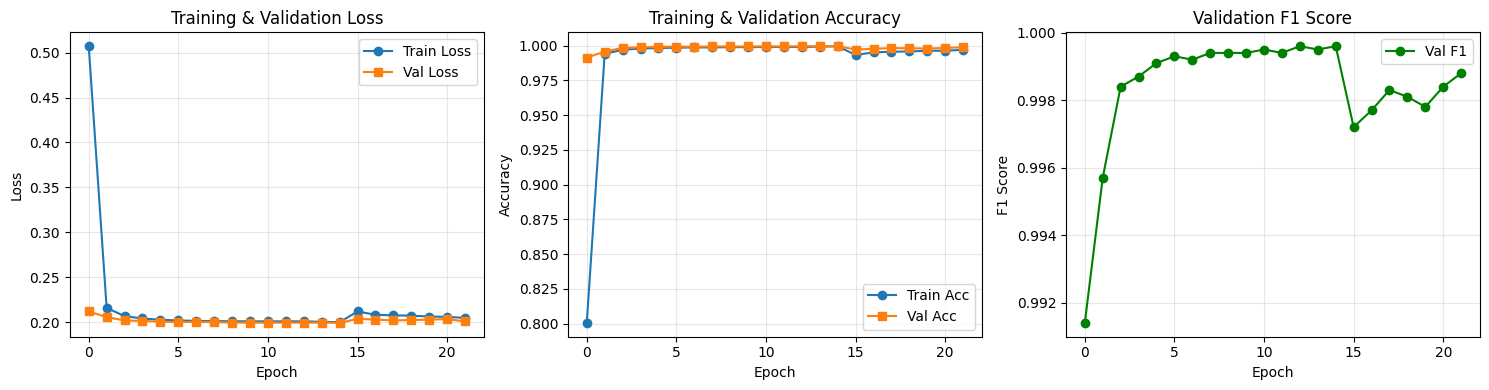

📊 Training history saved to /content/training_history.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score plot
axes[2].plot(history['val_f1'], label='Val F1', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

print("📊 Training history saved to /content/training_history.png")

In [11]:
# Quick Resume Cell - Run this first if runtime was restarted
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Re-define the model architecture (copy from your Step 7/8)
class DeepfakeDetector(nn.Module):
    # ... paste your model class definition here ...
    pass

# Then you can load your trained weights

Using device: cpu


## Step 11: Evaluate on Test Set

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
checkpoint = torch.load('/content/best_deepfake_detector.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of being fake

# Print classification report
print("\n📊 Classification Report:")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Calculate final metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='binary')
test_precision = precision_score(all_labels, all_preds, average='binary')
test_recall = recall_score(all_labels, all_preds, average='binary')

print(f"\n🎯 Final Test Metrics:")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall: {test_recall:.4f}")
print(f"   F1 Score: {test_f1:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_deepfake_detector.pth'

## Step 12: Export Model for DeepGuard Backend

In [ ]:
import torch

# Load best model
checkpoint = torch.load('/content/best_deepfake_detector.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Save model in different formats

# 1. Save full model (for PyTorch)
torch.save(model.state_dict(), '/content/deepfake_detector_state_dict.pth')
print("✅ Saved: deepfake_detector_state_dict.pth")

# 2. Save with model architecture (complete save)
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'EfficientNet-B0',
    'num_classes': 2,
    'input_size': (224, 224),
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
    'classes': ['real', 'fake'],
    'test_accuracy': test_acc,
    'test_f1': test_f1,
}, '/content/deepfake_detector_complete.pth')
print("✅ Saved: deepfake_detector_complete.pth")

# 3. Export to TorchScript (for production)
model_scripted = torch.jit.script(model.cpu())
model_scripted.save('/content/deepfake_detector_scripted.pt')
print("✅ Saved: deepfake_detector_scripted.pt (TorchScript)")

# 4. Export to ONNX (for cross-platform deployment)
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model.cpu(),
    dummy_input,
    '/content/deepfake_detector.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("✅ Saved: deepfake_detector.onnx (ONNX)")

print("\n📦 All model exports complete!")
print("\nTo use in DeepGuard backend, download these files and place in ml/checkpoints/")

## Step 13: Download Models

In [14]:
from google.colab import files

print("📥 Downloading trained models...\n")

# Download the complete model (recommended)
files.download('/content/deepfake_detector_complete.pth')

# Optionally download other formats
# files.download('/content/deepfake_detector_scripted.pt')
# files.download('/content/deepfake_detector.onnx')

print("\n✅ Download complete!")
print("\nPlace the model in: DeepGuard/ml/checkpoints/deepfake_detector_complete.pth")

📥 Downloading trained models...



FileNotFoundError: Cannot find file: /content/deepfake_detector_complete.pth